# Extract and compare multi-group cross sections from different libraries

In [1]:
import sandy
import matplotlib.pyplot as plt

Failed to extract font properties from /usr/share/fonts/truetype/noto/NotoColorEmoji.ttf: Non-scalable fonts are not supported


generated new fontManager


The case study will be Pb206.

## Create non-shielded multi-group cross section files in GENDF format

For JEFF-3.3 using the ECCO 33-group energy structure (`ign=19`).

In [2]:
gendf_file_jeff33 = sandy.get_endf6_file("jeff_33", "xs", 822060).get_gendf(
    groupr_kws=dict(ign=19),
)


 njoy 2016.79  18Mar25                                       06/29/26 17:17:31
 *****************************************************************************

 moder...                                                                 0.0s

 reconr...                                                                0.1s



 moder...                                                                 2.0s



 groupr...                                                                3.1s



 moder...                                                                 3.4s
                                                                          3.4s
 *****************************************************************************


For ENDF/B-VIII.1 using the ECCO 33-group energy structure (`ign=19`).

In [3]:
gendf_file_endfb81 = sandy.get_endf6_file("endfb_81", "xs", 822060).get_gendf(
    groupr_kws=dict(ign=19),
)


 njoy 2016.79  18Mar25                                       06/29/26 17:17:37
 *****************************************************************************

 moder...                                                                 0.0s



 reconr...                                                                0.4s

 ---message from rdf2bw---calculation of angular distribution not installed.



 moder...                                                                 2.8s



 groupr...                                                                4.0s



 moder...                                                                 4.4s
                                                                          4.4s
 *****************************************************************************


## Extract cross sections and caclulate relative difference 

For plotting purposes I change the series index using only the right boundary of each group. Then i can plot it using `ds="steps-pre"`.

In [4]:
xs_jeff33 = gendf_file_jeff33.get_xs().data.pipe(lambda x: x.set_axis(x.index.right, axis=0))
xs_endfb81 = gendf_file_endfb81.get_xs().data.pipe(lambda x: x.set_axis(x.index.right, axis=0))

I calculate the relative difference between the two cross sections in percent, keeping the energy dependence.

In [5]:
delta = (xs_jeff33 / xs_endfb81 - 1) * 100

Here I visually compare the elastic scattering, inelastic scattering, capture and total cross sections.

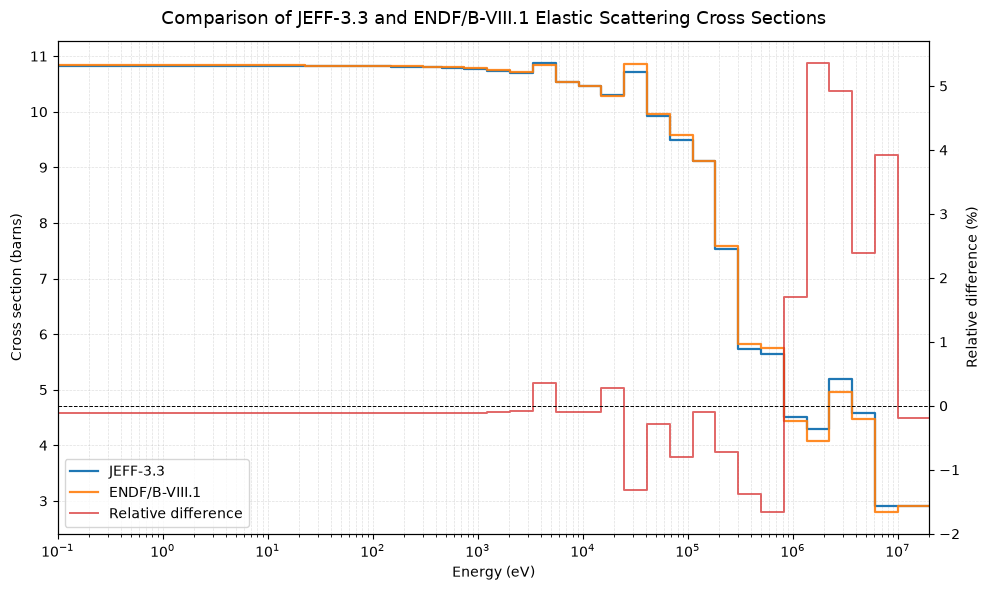

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

# --- Main XS plots ---
xs_jeff33[8231, 2].plot(drawstyle="steps-pre", ax=ax, label="JEFF-3.3", color="tab:blue", lw=1.6)
xs_endfb81[8231, 2].plot(drawstyle="steps-pre", ax=ax, label="ENDF/B-VIII.1", color="tab:orange", lw=1.6, alpha=0.9)

# --- Relative difference on secondary axis ---
ax2 = ax.twinx()
delta[8231, 2].plot(drawstyle="steps-pre", ax=ax2, label="Relative difference", color="tab:red", lw=1.4, alpha=0.7)

# --- Axis labels ---
ax.set(
    xlabel="Energy (eV)",
    ylabel="Cross section (barns)",
    xlim=(1e-1, 2e7),
    xscale="log",
)
ax2.set_ylabel("Relative difference (%)")

# --- Legends ---
lns1, labs1 = ax.get_legend_handles_labels()
lns2, labs2 = ax2.get_legend_handles_labels()
ax2.legend(
    lns1 + lns2, labs1 + labs2,
    loc=3, frameon=True, fontsize=10,
)
ax2.axhline(0, color="k", lw=.7, ls='--')

# --- Grid & style ---
ax.grid(True, which="both", ls="--", lw=0.5, alpha=0.4)
ax.set_axisbelow(True)

# --- Title & aesthetics ---
ax.set_title("Comparison of JEFF-3.3 and ENDF/B-VIII.1 Elastic Scattering Cross Sections", fontsize=13, pad=12)
fig.tight_layout()

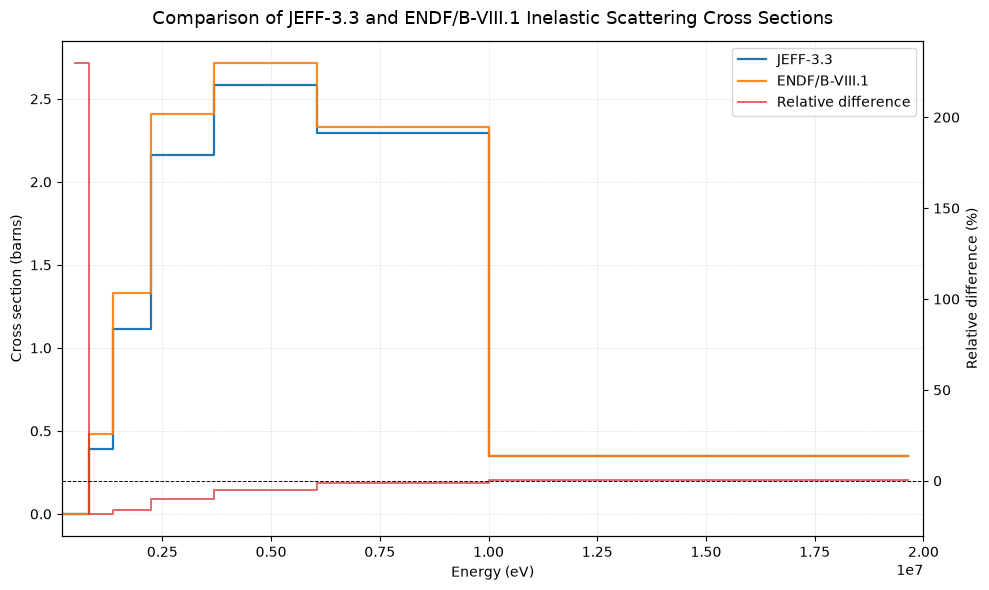

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

# --- Main XS plots ---
xs_jeff33[8231, 4].plot(drawstyle="steps-pre", ax=ax, label="JEFF-3.3", color="tab:blue", lw=1.6)
xs_endfb81[8231, 4].plot(drawstyle="steps-pre", ax=ax, label="ENDF/B-VIII.1", color="tab:orange", lw=1.6, alpha=0.9)

# --- Relative difference on secondary axis ---
ax2 = ax.twinx()
delta[8231, 4].plot(drawstyle="steps-pre", ax=ax2, label="Relative difference", color="tab:red", lw=1.4, alpha=0.7)

# --- Axis labels ---
xlow = min(xs_jeff33[xs_jeff33[8231, 4]>0].index[0], xs_endfb81[xs_endfb81[8231, 4]>0].index[0])
ax.set(
    xlabel="Energy (eV)",
    ylabel="Cross section (barns)",
    xlim=(xlow, 2e7),
)
ax2.set_ylabel("Relative difference (%)")

# --- Legends ---
lns1, labs1 = ax.get_legend_handles_labels()
lns2, labs2 = ax2.get_legend_handles_labels()
ax2.legend(
    lns1 + lns2, labs1 + labs2,
    loc=1, frameon=True, fontsize=10,
)
ax2.axhline(0, color="k", lw=.7, ls='--')

# --- Grid & style ---
ax.grid(True, which="both", ls="--", lw=0.5, alpha=0.4)
ax.set_axisbelow(True)

# --- Title & aesthetics ---
ax.set_title("Comparison of JEFF-3.3 and ENDF/B-VIII.1 Inelastic Scattering Cross Sections", fontsize=13, pad=12)
fig.tight_layout()

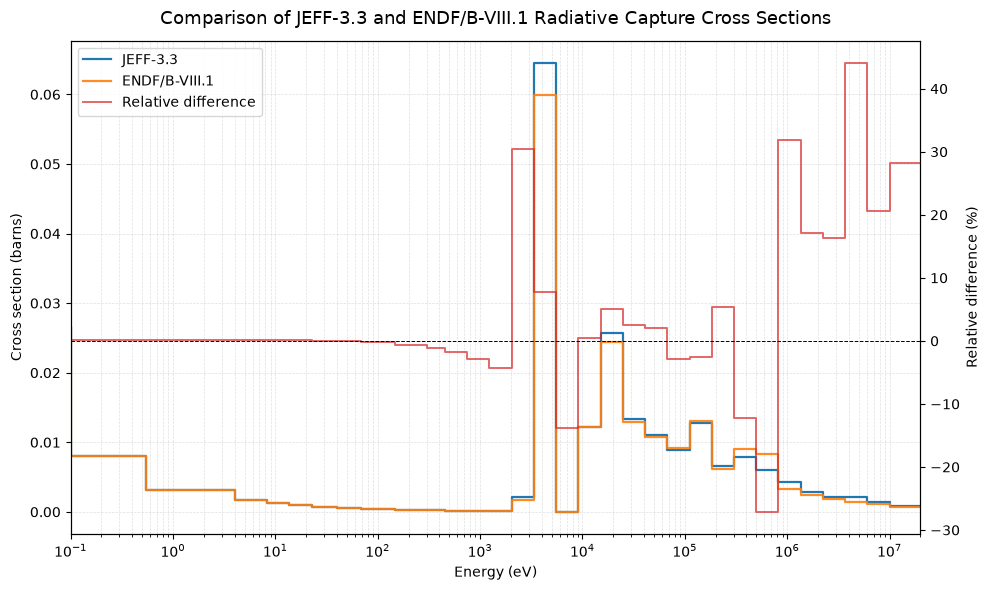

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

# --- Main XS plots ---
xs_jeff33[8231, 102].plot(drawstyle="steps-pre", ax=ax, label="JEFF-3.3", color="tab:blue", lw=1.6)
xs_endfb81[8231, 102].plot(drawstyle="steps-pre", ax=ax, label="ENDF/B-VIII.1", color="tab:orange", lw=1.6, alpha=0.9)

# --- Relative difference on secondary axis ---
ax2 = ax.twinx()
delta[8231, 102].plot(drawstyle="steps-pre", ax=ax2, label="Relative difference", color="tab:red", lw=1.4, alpha=0.7)

# --- Axis labels ---
ax.set(
    xlabel="Energy (eV)",
    ylabel="Cross section (barns)",
    xlim=(1e-1, 2e7),
    xscale="log",
)
ax2.set_ylabel("Relative difference (%)")

# --- Legends ---
lns1, labs1 = ax.get_legend_handles_labels()
lns2, labs2 = ax2.get_legend_handles_labels()
ax2.legend(
    lns1 + lns2, labs1 + labs2,
    loc=2, frameon=True, fontsize=10,
)
ax2.axhline(0, color="k", lw=.7, ls='--')

# --- Grid & style ---
ax.grid(True, which="both", ls="--", lw=0.5, alpha=0.4)
ax.set_axisbelow(True)

# --- Title & aesthetics ---
ax.set_title("Comparison of JEFF-3.3 and ENDF/B-VIII.1 Radiative Capture Cross Sections", fontsize=13, pad=12)
fig.tight_layout()

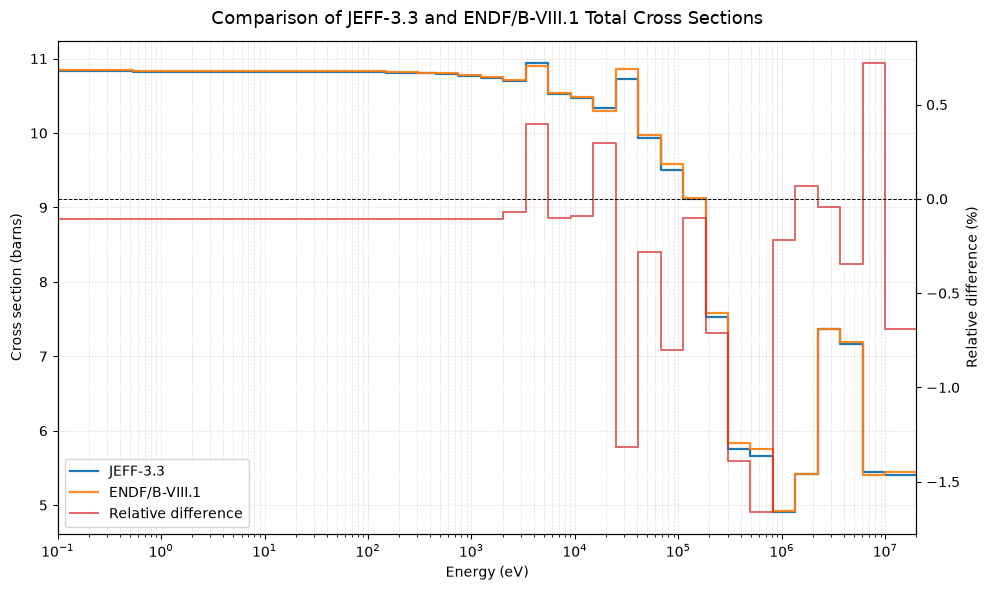

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

# --- Main XS plots ---
xs_jeff33[8231, 1].plot(drawstyle="steps-pre", ax=ax, label="JEFF-3.3", color="tab:blue", lw=1.6)
xs_endfb81[8231, 1].plot(drawstyle="steps-pre", ax=ax, label="ENDF/B-VIII.1", color="tab:orange", lw=1.6, alpha=0.9)

# --- Relative difference on secondary axis ---
ax2 = ax.twinx()
delta[8231, 1].plot(drawstyle="steps-pre", ax=ax2, label="Relative difference", color="tab:red", lw=1.4, alpha=0.7)

# --- Axis labels ---
ax.set(
    xlabel="Energy (eV)",
    ylabel="Cross section (barns)",
    xlim=(1e-1, 2e7),
    xscale="log",
)
ax2.set_ylabel("Relative difference (%)")

# --- Legends ---
lns1, labs1 = ax.get_legend_handles_labels()
lns2, labs2 = ax2.get_legend_handles_labels()
ax2.legend(
    lns1 + lns2, labs1 + labs2,
    loc=3, frameon=True, fontsize=10,
)
ax2.axhline(0, color="k", lw=.7, ls='--')

# --- Grid & style ---
ax.grid(True, which="both", ls="--", lw=0.5, alpha=0.4)
ax.set_axisbelow(True)

# --- Title & aesthetics ---
ax.set_title("Comparison of JEFF-3.3 and ENDF/B-VIII.1 Total Cross Sections", fontsize=13, pad=12)
fig.tight_layout()